In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

import re
import nltk
import pymorphy3

import gensim

import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

In [ ]:
import pandas as pd
import os

df_movies = pd.read_csv("kinopoisk_top250.csv")

df_combined = pd.DataFrame({
    'title': df_movies['title'],
    'namecompany': df_movies['title'],
    'description': df_movies['genre'],
    'rating': df_movies['rating'],
    'field': df_movies['genre'],
    'date': df_movies['year'],
    'textpub': df_movies['description']
})

df_combined.to_csv("All_Habr.csv", index=False)


In [3]:
df = pd.read_csv('All_Habr.csv')

In [4]:
df.head()

,title,namecompany,description,rating,field,date,textpub
0,Зеленая миля,Зеленая миля,"драма, фэнтези, криминал",9.1,"драма, фэнтези, криминал",1999,Пол Эджкомб — начальник блока смертников в тюр...
1,Побег из Шоушенка,Побег из Шоушенка,драма,9.1,драма,1994,Бухгалтер Энди Дюфрейн обвинён в убийстве собс...
2,Форрест Гамп,Форрест Гамп,"драма, комедия, мелодрама, история, военный",8.9,"драма, комедия, мелодрама, история, военный",1994,"Сидя на автобусной остановке, Форрест Гамп — н..."
3,1+1,1+1,"драма, комедия",8.9,"драма, комедия",2011,"Пострадав в результате несчастного случая, бог..."
4,Список Шиндлера,Список Шиндлера,"биография, история, драма, военный",8.9,"биография, история, драма, военный",1993,"Оскар Шиндлер, член национал-социалистической ..."


In [5]:
df['textpub'][0]

'Пол Эджкомб\xa0—\xa0начальник блока смертников в\xa0тюрьме «Холодная гора», каждый из\xa0узников которого однажды проходит «зеленую милю» по\xa0пути к\xa0месту казни. Пол\xa0повидал много заключённых и\xa0надзирателей за\xa0время работы. Однако гигант Джон Коффи, обвинённый в\xa0страшном преступлении, стал одним из\xa0самых необычных обитателей блока.'

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   title        250 non-null    str    
 1   namecompany  250 non-null    str    
 2   description  250 non-null    str    
 3   rating       250 non-null    float64
 4   field        250 non-null    str    
 5   date         250 non-null    int64  
 6   textpub      250 non-null    str    
dtypes: float64(1), int64(1), str(5)
memory usage: 13.8 KB


In [7]:
df['corpus'] = (df['title'].fillna('') + ' ' + 
                df['textpub'].fillna(''))

### Предобработка текста

In [8]:
st = '\xa0—'
def remove_othersymbol(text):
    return ''.join([ch if ch not in st else ' ' for ch in text])

In [9]:
df['prep_text']= [remove_othersymbol(text.lower()) for text in df['corpus']]

In [10]:
df['prep_text'][0]

'зеленая миля пол эджкомб   начальник блока смертников в тюрьме «холодная гора», каждый из узников которого однажды проходит «зеленую милю» по пути к месту казни. пол повидал много заключённых и надзирателей за время работы. однако гигант джон коффи, обвинённый в страшном преступлении, стал одним из самых необычных обитателей блока.'

In [11]:
def remove_punctuation(text):
    return ''.join([ch for ch in text if ch not in string.punctuation])

In [12]:
df['prep_text']= [remove_punctuation(text) for text in df['prep_text']]

In [13]:
df['prep_text'][0]

'зеленая миля пол эджкомб   начальник блока смертников в тюрьме «холодная гора» каждый из узников которого однажды проходит «зеленую милю» по пути к месту казни пол повидал много заключённых и надзирателей за время работы однако гигант джон коффи обвинённый в страшном преступлении стал одним из самых необычных обитателей блока'

In [14]:
df.head()

,title,namecompany,description,rating,field,date,textpub,corpus,prep_text
0,Зеленая миля,Зеленая миля,"драма, фэнтези, криминал",9.1,"драма, фэнтези, криминал",1999,Пол Эджкомб — начальник блока смертников в тюр...,Зеленая миля Пол Эджкомб — начальник блока сме...,зеленая миля пол эджкомб начальник блока сме...
1,Побег из Шоушенка,Побег из Шоушенка,драма,9.1,драма,1994,Бухгалтер Энди Дюфрейн обвинён в убийстве собс...,Побег из Шоушенка Бухгалтер Энди Дюфрейн обвин...,побег из шоушенка бухгалтер энди дюфрейн обвин...
2,Форрест Гамп,Форрест Гамп,"драма, комедия, мелодрама, история, военный",8.9,"драма, комедия, мелодрама, история, военный",1994,"Сидя на автобусной остановке, Форрест Гамп — н...","Форрест Гамп Сидя на автобусной остановке, Фор...",форрест гамп сидя на автобусной остановке форр...
3,1+1,1+1,"драма, комедия",8.9,"драма, комедия",2011,"Пострадав в результате несчастного случая, бог...","1+1 Пострадав в результате несчастного случая,...",11 пострадав в результате несчастного случая б...
4,Список Шиндлера,Список Шиндлера,"биография, история, драма, военный",8.9,"биография, история, драма, военный",1993,"Оскар Шиндлер, член национал-социалистической ...","Список Шиндлера Оскар Шиндлер, член национал-с...",список шиндлера оскар шиндлер член националсоц...


In [15]:
import nltk
nltk.download('stopwords')
russian_stopwords = stopwords.words("russian") 

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [16]:
russian_stopwords.extend(['т.д.', 'т', 'д', 'это','который','свой','своём','всем','всё','её','оба','ещё','должный','фильм', 'кино', 'смотреть', 'год', 'снят', 'рассказывает', 'история', 
                'оказывается', 'вдруг', 'наконец', 'также', 'персонаж', 'жизнь', 'картина', 'режиссер'])

In [17]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [18]:
morph = pymorphy3.MorphAnalyzer(lang='ru')

In [19]:
%%time
lemm_texts_list = []
for text in (df['prep_text']):
    try:
        tokens = word_tokenize(text)
        res = list()
        for word in tokens:
            p = morph.parse(word)[0]
            res.append(p.normal_form)
        text = " ".join(res)
        lemm_texts_list.append(text)
    except Exception as e:
        print(e)
    
df['text_lemm'] = lemm_texts_list

CPU times: total: 1.14 s
Wall time: 1.15 s


In [20]:
df.head()

,title,namecompany,description,rating,field,date,textpub,corpus,prep_text,text_lemm
0,Зеленая миля,Зеленая миля,"драма, фэнтези, криминал",9.1,"драма, фэнтези, криминал",1999,Пол Эджкомб — начальник блока смертников в тюр...,Зеленая миля Пол Эджкомб — начальник блока сме...,зеленая миля пол эджкомб начальник блока сме...,зелёный миля пол эджкомба начальник блок смерт...
1,Побег из Шоушенка,Побег из Шоушенка,драма,9.1,драма,1994,Бухгалтер Энди Дюфрейн обвинён в убийстве собс...,Побег из Шоушенка Бухгалтер Энди Дюфрейн обвин...,побег из шоушенка бухгалтер энди дюфрейн обвин...,побег из шоушенка бухгалтер энди дюфрейн обвин...
2,Форрест Гамп,Форрест Гамп,"драма, комедия, мелодрама, история, военный",8.9,"драма, комедия, мелодрама, история, военный",1994,"Сидя на автобусной остановке, Форрест Гамп — н...","Форрест Гамп Сидя на автобусной остановке, Фор...",форрест гамп сидя на автобусной остановке форр...,форресть гампа сидя на автобусный остановка фо...
3,1+1,1+1,"драма, комедия",8.9,"драма, комедия",2011,"Пострадав в результате несчастного случая, бог...","1+1 Пострадав в результате несчастного случая,...",11 пострадав в результате несчастного случая б...,11 пострадать в результат несчастный случай бо...
4,Список Шиндлера,Список Шиндлера,"биография, история, драма, военный",8.9,"биография, история, драма, военный",1993,"Оскар Шиндлер, член национал-социалистической ...","Список Шиндлера Оскар Шиндлер, член национал-с...",список шиндлера оскар шиндлер член националсоц...,список шиндлера оскар шиндлера член националсо...


In [21]:
df['text_lemm'][0]

'зелёный миля пол эджкомба начальник блок смертник в тюрьма « холодный гора » каждый из узник который однажды проходить « зелёный миля » по путь к место казнь пол повидать много заключить и надзиратель за время работа однако гигант джон коффи обвинить в страшный преступление стать один из самый необычный обитатель блок'

In [22]:
def clean_textpub(text):
    text = re.sub(r'\b\w*\d\w*\b', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    
    return text

In [23]:
def tokenize(text):
    t = word_tokenize(text)
    tokens = [token for token in t if token not in russian_stopwords and len(t) > 2]
    text = " ".join(tokens)
    return clean_textpub(text)

In [24]:
df['tokenize_text'] = [tokenize(text) for text in df['text_lemm']]

In [25]:
df.head()

,title,namecompany,description,rating,field,date,textpub,corpus,prep_text,text_lemm,tokenize_text
0,Зеленая миля,Зеленая миля,"драма, фэнтези, криминал",9.1,"драма, фэнтези, криминал",1999,Пол Эджкомб — начальник блока смертников в тюр...,Зеленая миля Пол Эджкомб — начальник блока сме...,зеленая миля пол эджкомб начальник блока сме...,зелёный миля пол эджкомба начальник блок смерт...,зелёный миля пол эджкомба начальник блок смерт...
1,Побег из Шоушенка,Побег из Шоушенка,драма,9.1,драма,1994,Бухгалтер Энди Дюфрейн обвинён в убийстве собс...,Побег из Шоушенка Бухгалтер Энди Дюфрейн обвин...,побег из шоушенка бухгалтер энди дюфрейн обвин...,побег из шоушенка бухгалтер энди дюфрейн обвин...,побег шоушенка бухгалтер энди дюфрейн обвинить...
2,Форрест Гамп,Форрест Гамп,"драма, комедия, мелодрама, история, военный",8.9,"драма, комедия, мелодрама, история, военный",1994,"Сидя на автобусной остановке, Форрест Гамп — н...","Форрест Гамп Сидя на автобусной остановке, Фор...",форрест гамп сидя на автобусной остановке форр...,форресть гампа сидя на автобусный остановка фо...,форресть гампа сидя автобусный остановка форре...
3,1+1,1+1,"драма, комедия",8.9,"драма, комедия",2011,"Пострадав в результате несчастного случая, бог...","1+1 Пострадав в результате несчастного случая,...",11 пострадав в результате несчастного случая б...,11 пострадать в результат несчастный случай бо...,пострадать результат несчастный случай богат...
4,Список Шиндлера,Список Шиндлера,"биография, история, драма, военный",8.9,"биография, история, драма, военный",1993,"Оскар Шиндлер, член национал-социалистической ...","Список Шиндлера Оскар Шиндлер, член национал-с...",список шиндлера оскар шиндлер член националсоц...,список шиндлера оскар шиндлера член националсо...,список шиндлера оскар шиндлера член националсо...


In [26]:
df['tokenize_text'][0]

'зелёный миля пол эджкомба начальник блок смертник тюрьма   холодный гора   каждый узник однажды проходить   зелёный миля   путь место казнь пол повидать заключить надзиратель время работа однако гигант джон коффи обвинить страшный преступление стать самый необычный обитатель блок'

In [27]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
%matplotlib inline

In [28]:
def str_corpus(corpus):
    str_corpus = ''
    for i in corpus:
        str_corpus += ' ' + i
    str_corpus = str_corpus.strip()
    return str_corpus

def get_corpus(data):
    corpus = []
    for phrase in data:
        for word in phrase.split():
            corpus.append(word)
    return corpus

def get_wordCloud(corpus):
    wordCloud = WordCloud(background_color='white',
                              stopwords=STOPWORDS,
                              width=3000,
                              height=2500,
                              max_words=200,
                              random_state=42
                         ).generate(str_corpus(corpus))
    return wordCloud

<Axes: >

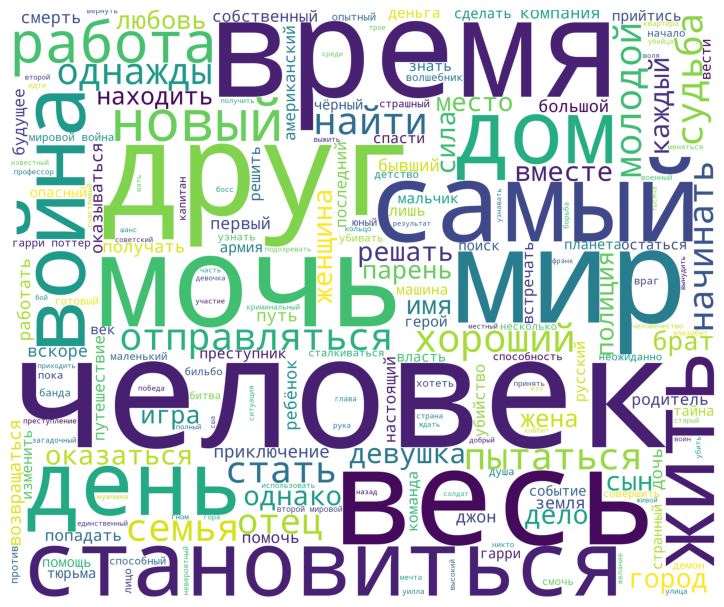

In [29]:
corpus = get_corpus(df['tokenize_text'].values)
procWordCloud = get_wordCloud(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)

In [30]:
def get_wordCloud2(corpus):
    wordCloud = WordCloud(background_color='white',
                              stopwords=STOPWORDS,
                              width=3000,
                              height=2500,
                              max_words=200,
                              random_state=42
                         ).generate(corpus)
    return wordCloud

<Axes: >

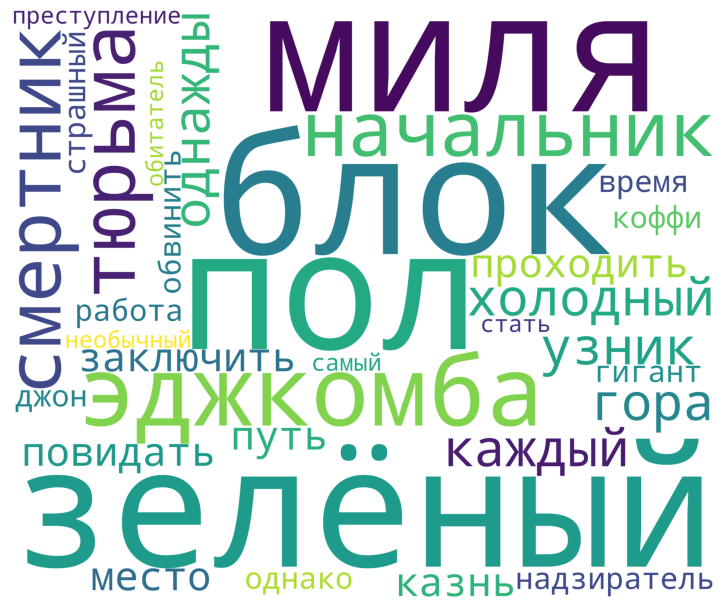

In [31]:
corpus = df['tokenize_text'][0]
procWordCloud = get_wordCloud2(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)

<Axes: >

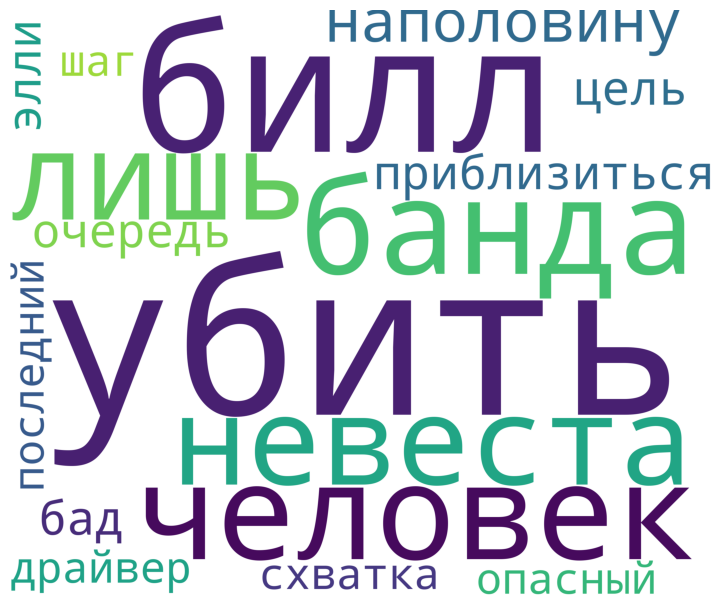

In [32]:
corpus = df['tokenize_text'][len(df)-1]
procWordCloud = get_wordCloud2(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)

<Axes: >

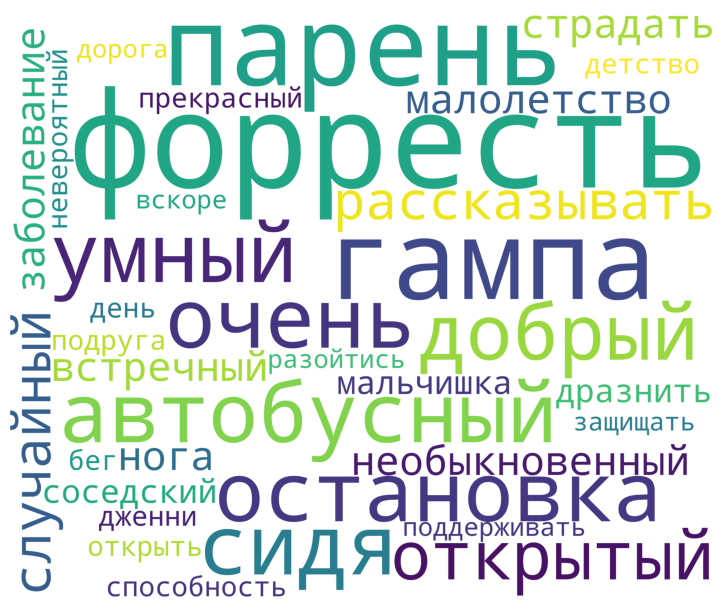

In [33]:
corpus = df['tokenize_text'][2]
procWordCloud = get_wordCloud2(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)

In [34]:
df.head()

,title,namecompany,description,rating,field,date,textpub,corpus,prep_text,text_lemm,tokenize_text
0,Зеленая миля,Зеленая миля,"драма, фэнтези, криминал",9.1,"драма, фэнтези, криминал",1999,Пол Эджкомб — начальник блока смертников в тюр...,Зеленая миля Пол Эджкомб — начальник блока сме...,зеленая миля пол эджкомб начальник блока сме...,зелёный миля пол эджкомба начальник блок смерт...,зелёный миля пол эджкомба начальник блок смерт...
1,Побег из Шоушенка,Побег из Шоушенка,драма,9.1,драма,1994,Бухгалтер Энди Дюфрейн обвинён в убийстве собс...,Побег из Шоушенка Бухгалтер Энди Дюфрейн обвин...,побег из шоушенка бухгалтер энди дюфрейн обвин...,побег из шоушенка бухгалтер энди дюфрейн обвин...,побег шоушенка бухгалтер энди дюфрейн обвинить...
2,Форрест Гамп,Форрест Гамп,"драма, комедия, мелодрама, история, военный",8.9,"драма, комедия, мелодрама, история, военный",1994,"Сидя на автобусной остановке, Форрест Гамп — н...","Форрест Гамп Сидя на автобусной остановке, Фор...",форрест гамп сидя на автобусной остановке форр...,форресть гампа сидя на автобусный остановка фо...,форресть гампа сидя автобусный остановка форре...
3,1+1,1+1,"драма, комедия",8.9,"драма, комедия",2011,"Пострадав в результате несчастного случая, бог...","1+1 Пострадав в результате несчастного случая,...",11 пострадав в результате несчастного случая б...,11 пострадать в результат несчастный случай бо...,пострадать результат несчастный случай богат...
4,Список Шиндлера,Список Шиндлера,"биография, история, драма, военный",8.9,"биография, история, драма, военный",1993,"Оскар Шиндлер, член национал-социалистической ...","Список Шиндлера Оскар Шиндлер, член национал-с...",список шиндлера оскар шиндлер член националсоц...,список шиндлера оскар шиндлера член националсо...,список шиндлера оскар шиндлера член националсо...


# Векторизация текстовых данных

### Bag of words

In [35]:
count_vec = CountVectorizer(max_df=0.7, min_df=3, max_features=5000, ngram_range=(1, 3), analyzer='word')
count_matrix = count_vec.fit_transform(df['tokenize_text'])

feature_names = count_vec.get_feature_names_out()

In [36]:
len(count_vec.vocabulary_)

843

In [37]:
count_matrix.shape

(250, 843)

In [38]:
feature_names

array(['xx', 'xx век', 'автор', 'авторитет', 'агент', 'агент фбр',
       'адвокат', 'актёр', 'америка', 'американский', 'английский',
       'арестовывать', 'армия', 'банда', 'бандит', 'банк', 'безжалостный',
       'безопасность', 'белый', 'бесконечный', 'бизнесмен', 'бильбо',
       'битва', 'близкий', 'богатство', 'богатый', 'боевой', 'боец',
       'бой', 'боксёр', 'болезнь', 'больший', 'большой', 'бороться',
       'борьба', 'босс', 'брат', 'брать', 'браться', 'бросить', 'будущее',
       'будущий', 'бывалый', 'бывший', 'быстро', 'быстрый', 'важный',
       'ведущий', 'век', 'великий', 'великолепный', 'вера', 'вернуть',
       'вернуться', 'верный', 'вести', 'весь', 'весь мир', 'весьма',
       'вечный', 'взгляд', 'взрослый', 'взять', 'вид', 'видение',
       'видеть', 'властелин', 'властелин кольцо', 'власть', 'влюбить',
       'вместе', 'вместо', 'внезапно', 'вновь', 'водитель', 'военный',
       'возвращаться', 'возвращение', 'возглавлять', 'возникать',
       'возраст', 'воин

### TF-IDF

In [39]:
tfidf_vectorizer = TfidfVectorizer(
    max_df=0.7,         
    min_df=3,            
    max_features=5000,   
    ngram_range=(1, 3),  
    analyzer='word'
)

In [40]:
tfidf_matrix = tfidf_vectorizer.fit_transform(df['tokenize_text'])

In [41]:
tfidf_matrix.shape

(250, 843)

In [42]:
print(tfidf_matrix)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4922 stored elements and shape (250, 843)>
  Coords	Values
  (0, 239)	0.48542969910218514
  (0, 387)	0.24271484955109257
  (0, 758)	0.19943979513198345
  (0, 138)	0.19943979513198345
  (0, 267)	0.160102730631216
  (0, 775)	0.23217611005446528
  (0, 430)	0.15809270306467868
  (0, 579)	0.24271484955109257
  (0, 586)	0.1802902784905332
  (0, 339)	0.1743790085909428
  (0, 225)	0.24271484955109257
  (0, 95)	0.13638967162561008
  (0, 591)	0.15809270306467868
  (0, 431)	0.164399193004467
  (0, 180)	0.1949384364755546
  (0, 723)	0.19943979513198345
  (0, 536)	0.20441581626819202
  (0, 713)	0.15081239472343544
  (0, 628)	0.15431240450884776
  (0, 400)	0.23217611005446528
  (0, 416)	0.2235653329096423
  (1, 758)	0.20434881262684157
  (1, 267)	0.16404350436257226
  (1, 225)	0.24868904061922756
  (1, 485)	0.23789090025163334
  :	:
  (247, 63)	0.2696842505055992
  (247, 653)	0.29278408882034035
  (247, 555)	0.29278408882034035
  (248, 59

In [43]:
tfidf_vectorizer.get_feature_names_out()[1165:1175]

array([], dtype=object)

# Тематическое моделирование

In [44]:
import gensim

In [45]:
def tokenize2(text):
    t = word_tokenize(text)
    tokens = [token for token in t if token not in russian_stopwords]
    return tokens

In [46]:
df['tokenize_text3'] = [tokenize2(text) for text in df['tokenize_text']]

In [47]:
gensim_dictionary = gensim.corpora.Dictionary(df['tokenize_text3'])
no_below_val = min(15, max(2, int(len(df) * 0.05)))
gensim_dictionary.filter_extremes(no_above=0.1, no_below=no_below_val)
gensim_dictionary.compactify()


In [48]:
corpus = [gensim_dictionary.doc2bow(text) 
          for text in df['tokenize_text3']]

In [49]:
df.head()

,title,namecompany,description,rating,field,date,textpub,corpus,prep_text,text_lemm,tokenize_text,tokenize_text3
0,Зеленая миля,Зеленая миля,"драма, фэнтези, криминал",9.1,"драма, фэнтези, криминал",1999,Пол Эджкомб — начальник блока смертников в тюр...,Зеленая миля Пол Эджкомб — начальник блока сме...,зеленая миля пол эджкомб начальник блока сме...,зелёный миля пол эджкомба начальник блок смерт...,зелёный миля пол эджкомба начальник блок смерт...,"[зелёный, миля, пол, эджкомба, начальник, блок..."
1,Побег из Шоушенка,Побег из Шоушенка,драма,9.1,драма,1994,Бухгалтер Энди Дюфрейн обвинён в убийстве собс...,Побег из Шоушенка Бухгалтер Энди Дюфрейн обвин...,побег из шоушенка бухгалтер энди дюфрейн обвин...,побег из шоушенка бухгалтер энди дюфрейн обвин...,побег шоушенка бухгалтер энди дюфрейн обвинить...,"[побег, шоушенка, бухгалтер, энди, дюфрейн, об..."
2,Форрест Гамп,Форрест Гамп,"драма, комедия, мелодрама, история, военный",8.9,"драма, комедия, мелодрама, история, военный",1994,"Сидя на автобусной остановке, Форрест Гамп — н...","Форрест Гамп Сидя на автобусной остановке, Фор...",форрест гамп сидя на автобусной остановке форр...,форресть гампа сидя на автобусный остановка фо...,форресть гампа сидя автобусный остановка форре...,"[форресть, гампа, сидя, автобусный, остановка,..."
3,1+1,1+1,"драма, комедия",8.9,"драма, комедия",2011,"Пострадав в результате несчастного случая, бог...","1+1 Пострадав в результате несчастного случая,...",11 пострадав в результате несчастного случая б...,11 пострадать в результат несчастный случай бо...,пострадать результат несчастный случай богат...,"[пострадать, результат, несчастный, случай, бо..."
4,Список Шиндлера,Список Шиндлера,"биография, история, драма, военный",8.9,"биография, история, драма, военный",1993,"Оскар Шиндлер, член национал-социалистической ...","Список Шиндлера Оскар Шиндлер, член национал-с...",список шиндлера оскар шиндлер член националсоц...,список шиндлера оскар шиндлера член националсо...,список шиндлера оскар шиндлера член националсо...,"[список, шиндлера, оскар, шиндлера, член, наци..."


In [50]:
corpus

[[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1)],
 [(0, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1)],
 [(13, 1), (14, 2)],
 [(5, 1), (15, 1), (16, 1)],
 [(17, 1), (18, 1), (19, 1)],
 [(6, 1), (10, 1), (16, 1), (20, 1)],
 [(2, 1), (21, 1), (22, 1), (23, 1), (24, 1), (25, 1), (26, 1)],
 [],
 [(27, 1), (28, 1), (29, 1)],
 [(30, 1), (31, 1), (32, 1)],
 [(7, 1), (10, 1), (17, 1), (33, 1)],
 [(6, 1),
  (7, 1),
  (9, 1),
  (15, 1),
  (21, 1),
  (32, 1),
  (34, 1),
  (35, 2),
  (36, 1),
  (37, 1)],
 [(0, 1), (38, 1), (39, 1), (40, 1), (41, 2)],
 [(7, 1), (21, 1), (22, 2), (29, 2), (32, 3), (42, 1)],
 [(17, 1), (18, 1), (32, 3), (37, 1), (38, 1), (43, 1), (44, 1), (45, 1)],
 [(40, 1), (46, 1)],
 [(7, 1), (37, 1), (45, 1), (47, 1), (48, 1)],
 [(3, 1), (10, 1), (13, 1), (32, 1), (37, 2), (45, 1), (48, 1), (49, 1)],
 [(31, 1), (40, 1), (49, 1), (50, 1)],
 [(10, 1), (15, 1), (47, 1)],
 [(0, 1), (27, 2)],
 [(9, 1), (25, 1), (34, 1), (35, 1), (49, 1)],
 [(29, 1), (51, 1)],
 [],
 []

In [51]:
lda_20 = gensim.models.LdaMulticore(corpus, 
                                 num_topics=7, 
                                 id2word=gensim_dictionary, 
                                 passes=10, random_state=6457)

In [52]:
lda_20.print_topics()

[(0,
  '0.093*"работа" + 0.089*"самый" + 0.064*"полиция" + 0.062*"женщина" + 0.054*"бывший" + 0.046*"каждый" + 0.044*"встречать" + 0.039*"дочь" + 0.037*"однажды" + 0.037*"ребёнок"'),
 (1,
  '0.113*"начинать" + 0.079*"найти" + 0.070*"судьба" + 0.062*"отец" + 0.056*"самый" + 0.052*"оказаться" + 0.043*"смерть" + 0.040*"пытаться" + 0.040*"имя" + 0.037*"убийство"'),
 (2,
  '0.075*"находить" + 0.075*"дом" + 0.066*"жена" + 0.055*"место" + 0.050*"новый" + 0.047*"любовь" + 0.047*"первый" + 0.047*"американский" + 0.041*"будущее" + 0.037*"век"'),
 (3,
  '0.074*"вместе" + 0.067*"земля" + 0.062*"компания" + 0.061*"работать" + 0.061*"мировой" + 0.057*"решать" + 0.055*"второй" + 0.050*"большой" + 0.048*"сила" + 0.046*"судьба"'),
 (4,
  '0.118*"парень" + 0.092*"однажды" + 0.087*"жить" + 0.083*"девушка" + 0.080*"помочь" + 0.064*"имя" + 0.063*"отправляться" + 0.051*"семья" + 0.037*"молодой" + 0.025*"новый"'),
 (5,
  '0.216*"хороший" + 0.131*"пытаться" + 0.065*"каждый" + 0.059*"смерть" + 0.050*"решить" +

In [53]:
from sklearn.decomposition import LatentDirichletAllocation

In [54]:
n_topics = 7
n_top_words = 10

print("\n" + "="*60)
print("LDA (Латентное размещение Дирихле)")
print("="*60)
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=100)
lda.fit(count_matrix)

def print_topics(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Тема {topic_idx + 1}:")
        top_words_idx = topic.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(" ".join(top_words))
        print()

print_topics(lda, feature_names, n_top_words)


LDA (Латентное размещение Дирихле)


Тема 1:
джек человек элизабет капитан игра дом начинать уилла проклятие друг

Тема 2:
мир весь молодой человек демон мочь стать становиться дом работа

Тема 3:
гарри гарри поттер поттер друг человек хогвартс несколько время война компания

Тема 4:
человек друг день время мир оказаться найти судьба город путешествие

Тема 5:
полиция дело весь фрэнк джон время русский большой жить миллион

Тема 6:
человек бильбо новый однако сын земля день кольцо волшебник война

Тема 7:
время друг война мочь хороший пытаться весь мир второй жить



In [55]:
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

In [56]:
vis_20 = gensimvis.prepare(lda_20, corpus, gensim_dictionary)

In [57]:
pyLDAvis.enable_notebook()

In [58]:
vis_20

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2      0.052234 -0.088084       1        1  17.591057
6      0.006795 -0.193981       2        1  16.947994
0      0.124656  0.012816       3        1  15.605561
3     -0.137635  0.003531       4        1  13.793011
1      0.000097  0.181712       5        1  13.533751
4      0.195826  0.057371       6        1  12.375360
5     -0.241974  0.026635       7        1  10.153266, topic_info=            Term       Freq      Total Category  logprob  loglift
41       хороший  26.000000  26.000000  Default  30.0000  30.0000
26      пытаться  23.000000  23.000000  Default  29.0000  29.0000
14        парень  17.000000  17.000000  Default  28.0000  28.0000
24      начинать  20.000000  20.000000  Default  27.0000  27.0000
29  отправляться  23.000000  23.000000  Default  26.0000  26.0000
..           ...        ...        ...      ...      ...      ...
31        решать   0.356868  18.976173   Topic7  -5.7360  -1.6862
21     встречать   0.162378  12.437376   Topic7  -6.5235  -2.0512
18       мировой   0.163843  13.117687   Topic7  -6.5145  -2.0954
15       молодой   0.254736  22.597734   Topic7  -6.0732  -2.1980
6          самый   0.225159  27.618055   Topic7  -6.1966  -2.5220

[247 rows x 6 columns], token_table=      Topic      Freq          Term
term                               
51        1  0.703281  американский
51        2  0.078142  американский
51        3  0.078142  американский
51        5  0.078142  американский
27        2  0.283172       большой
...     ...       ...           ...
12        3  0.161433      убийство
12        5  0.403582      убийство
12        6  0.242149      убийство
41        3  0.075879       хороший
41        7  0.910543       хороший

[224 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 7, 1, 4, 2, 5, 6])

In [59]:
from gensim.models import CoherenceModel

coherence_model = CoherenceModel(model=lda_20,
                                 texts=df['tokenize_text3'],
                                 dictionary=gensim_dictionary,
                                 coherence="c_v")

coherence_value = coherence_model.get_coherence()
print(f"Когерентность модели: {coherence_value}")

Когерентность модели: 0.23562567323761227


In [60]:
from sklearn.decomposition import LatentDirichletAllocation

In [61]:
lda_model = LatentDirichletAllocation(n_components=7, random_state=0)
lda_model.fit(count_matrix)

for i, topic in enumerate(lda_model.components_):
    print(f"Topic {i}: {', '.join([count_vec.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: время, хороший, человек, первый, мечтать, школа, работа, день, весь, отец
Topic 1: время, война, игра, второй мировой, брат, второй, второй мировой война, мировой, мировой война, отправляться
Topic 2: дом, друг, джек, мир, элизабет, человек, время, родитель, парень, детство
Topic 3: друг, весь, демон, никто, стать, мечта, друг друг, человек, век, несколько
Topic 4: мир, весь, мочь, человек, война, женщина, друг, джон, находить, девушка
Topic 5: гарри, мир, становиться, поттер, гарри поттер, весь, война, друг, вскоре, спасти
Topic 6: человек, мочь, друг, чёрный, жить, найти, стать, кольцо, пытаться, каждый


In [62]:
lda_model = LatentDirichletAllocation(learning_method='online', random_state=5, n_jobs=-1, n_components=11)
lda_model.fit(tfidf_matrix)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",11
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'online'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [63]:
topic_keywords = pd.DataFrame()
for i,topic in enumerate(lda_model.components_):
    topic_keywords[f'Topic {i + 1}'] = [count_vec.get_feature_names_out()[i] for i in topic.argsort()[-10:]]
topic_keywords

,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10,Topic 11
0,подозревать,празднование,дом,решение,получать,ураган,кольцо,получать,кровавый,компания,попадать
1,человечество,лето,стать,спорт,часть,девушка,вынужденный,парень,являться,человек,любимый
2,среди,вступать,хороший,прошлый,узнавать,штат,война,убивать,магазин,мочь,дракон
3,существование,двое,война,боксёр,правда,похищать,музыкант,оборона,намеренный,мечта,место
4,кризис,кольцо,друг,далёкий,имя,личный,честь,счастливый,одновременно,друг,жестокий
5,крепость,охота,мочь,второй,превращаться,человек,отношение,заниматься,психиатрический,сын,уилла
6,отправляться,квартира,мир,наставник,обычный,просто,уничтожить,любой,правило,джек,дружба
7,путешествие,готовый,весь,фрэнк,реальность,кольцо,прийти,советский,друг,семья,перерастать
8,десять,реальность,время,пилот,меняться,планета,хитрый,гангстер,пёс,брат,вскоре
9,друг,сокровище,человек,криминальный,смочь,несмотря,влюбить,путь,преступник,каждый,подросток


In [64]:
from sklearn.decomposition import NMF

In [65]:
nmf_model = NMF(n_components=10, random_state=0)
nmf_model.fit(tfidf_matrix)

for i, topic in enumerate(nmf_model.components_):
    print(f"Topic {i}: {', '.join([tfidf_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: друг, однажды, жить, девушка, друг друг, дом, стать, любовь, парень, работа
Topic 1: война, второй, мировой война, второй мировой, второй мировой война, мировой, время второй мировой, время второй, время, немецкий
Topic 2: гарри, гарри поттер, поттер, хогвартс, школа, волшебник, чародейство волшебство хогвартс, чародейство волшебство, школа чародейство волшебство, курс школа чародейство
Topic 3: человек, планета, судьба, земля, путешествие, оказаться, странный, чёрный, мочь, русский
Topic 4: мир, команда, хороший, схватка, легенда, столкнуться, агент, талантливый, смертельный схватка, агент фбр
Topic 5: будущее, подросток, время, попадать, машина, помощь, назад, родитель, приходиться, будущий
Topic 6: самый, весь, полиция, игра, мочь, дело, день, помочь, город, молодой
Topic 7: джек, элизабет, уилла, капитан, пират, проклятие, море, свет, пират карибский, карибский море
Topic 8: кольцо, крепость, бильбо, армия, хоббит, уничтожить, властелин кольцо, властелин, гора, приближатьс

In [66]:
nmf_model = NMF(n_components=7, random_state=0)
nmf_model.fit(tfidf_matrix)

for i, topic in enumerate(nmf_model.components_):
    print(f"Topic {i}: {', '.join([tfidf_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: мочь, человек, весь, молодой, самый, работа, город, семья, дом, женщина
Topic 1: война, второй, мировой война, второй мировой, мировой, второй мировой война, время второй, время второй мировой, время, немецкий
Topic 2: гарри, гарри поттер, поттер, хогвартс, школа, волшебник, чародейство, чародейство волшебство хогвартс, курс школа, курс школа чародейство
Topic 3: друг, друг друг, однажды, жить, любовь, парень, хозяин, начинать, день, встречать
Topic 4: мир, команда, хороший, время, будущее, подросток, легенда, схватка, агент, мальчик
Topic 5: путешествие, планета, земля, кольцо, чёрный, джек, бильбо, элизабет, человек, хоббит
Topic 6: брат, оказываться, америка, отец, старший, работать, последний, мать, решать, компания


In [67]:
nmf_transformed = nmf_model.transform(tfidf_matrix)

print("\nТОП-3 СТАТЬИ ДЛЯ КАЖДОЙ ТЕМЫ:\n")
for topic_idx in range(n_topics):
    topic_scores = nmf_transformed[:, topic_idx]
    top_docs_idx = np.argsort(topic_scores)[-5:][::-1]
    
    print(f" Topic {topic_idx}")
    for rank, doc_idx in enumerate(top_docs_idx[:3], 1):
        title = df.iloc[doc_idx]['title']
        rating = df.iloc[doc_idx]['rating']
        score = topic_scores[doc_idx]
        print(f"   {rank}. {title} (рейтинг: {rating}) — уверенность: {score:.3f}")
    print()


ТОП-3 СТАТЬИ ДЛЯ КАЖДОЙ ТЕМЫ:

 Topic 0
   1. Деревья на асфальте (рейтинг: 8.7) — уверенность: 0.206
   2. Дело Коллини (рейтинг: 8.0) — уверенность: 0.183
   3. Марли и я (рейтинг: 7.8) — уверенность: 0.169

 Topic 1
   1. Игра в имитацию (рейтинг: 7.8) — уверенность: 0.536
   2. По соображениям совести (рейтинг: 8.2) — уверенность: 0.514
   3. Список Шиндлера (рейтинг: 8.9) — уверенность: 0.493

 Topic 2
   1. Гарри Поттер и Тайная комната (рейтинг: 8.2) — уверенность: 0.649
   2. Гарри Поттер и Кубок огня (рейтинг: 8.0) — уверенность: 0.633
   3. Гарри Поттер и узник Азкабана (рейтинг: 8.3) — уверенность: 0.593

 Topic 3
   1. Престиж (рейтинг: 8.5) — уверенность: 0.479
   2. Бойцовский клуб (рейтинг: 8.7) — уверенность: 0.434
   3. С любовью, Рози (рейтинг: 7.8) — уверенность: 0.400

 Topic 4
   1. Иллюзия обмана (рейтинг: 7.8) — уверенность: 0.441
   2. Пеле: Рождение легенды (рейтинг: 8.5) — уверенность: 0.361
   3. Назад в будущее 2 (рейтинг: 8.3) — уверенность: 0.355

 Topic 

In [68]:
from sklearn.decomposition import TruncatedSVD

In [69]:
lsa_model = TruncatedSVD(n_components=7, random_state=0)
lsa_model.fit(tfidf_matrix)

for i, topic in enumerate(lsa_model.components_):
    print(f"Topic {i}: {', '.join([tfidf_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: человек, друг, время, мочь, весь, мир, война, день, стать, судьба
Topic 1: война, мировой война, второй мировой, второй мировой война, мировой, второй, время второй мировой, время второй, время, американский
Topic 2: гарри, гарри поттер, поттер, хогвартс, школа, волшебник, война, опасность, курс школа чародейство, курс школа
Topic 3: друг, время, друг друг, однажды, встречать, жить, любовь, стать, место, вокзал
Topic 4: команда, хороший, мир, схватка, время, столкнуться, агент, легенда, играть, смертельный схватка
Topic 5: друг, джек, путешествие, элизабет, отправляться, уилла, капитан, планета, чёрный, война
Topic 6: брат, решать, кольцо, отец, полиция, дело, местный, принять, последний, власть


для топиков написать тему и сделать вывод совпал ли темы со статьями

### Анализ топиков

**Topic 0: Кибербезопасность и бизнес-процессы**
* **О чем:** Профессиональная деятельность аналитиков в сфере ИБ, поиск уязвимостей и корпоративные отчеты.
* **Вердикт:** **Полное совпадение.** Слова "атака", "уязвимость" и "безопасность" идеально ложатся в статью про будни аналитика ИБ. Третья статья про когнитивные искажения тоже в тему, так как это часть "процесса" и работы "специалиста".

**Topic 1: Экосистема Anthropic (Claude)**
* **О чем:** Использование моделей Claude, обход ограничений (VPN), работа с Claude Code и сравнение с OpenAI.
* **Вердикт:** **Полное совпадение.** Ключи "claude", "anthropic" и "vpn" четко отражают боли пользователей, которые пытаются достучаться до сервиса. Статьи про Claude Code и логи Anthropic подтверждают точность.

**Topic 2: Генеративный контент и ИИ-арт**
* **О чем:** Создание визуалов, промпт-инжиниринг и хайповые инструменты типа нанобанана.
* **Вердикт:** **Идеальное совпадение.** Тут модель сработала идеально. Ключевые слова "открытка", "кадр", "промт" и специфическое "banana" нашли свои статьи про пасхальные открытки и фотосессии.

**Topic 3: Технологические новости и тренды ИИ**
* **О чем:** Глобальные новости ИТ-рынка, слияния компаний, разработка чипов и прогнозы на будущее.
* **Вердикт:** **Совпало.** Топик получился немного обо всем, но статьи про чипы Anthropic и слияние компаний четко соответствуют ключам "новость", "технология", "будущее".

**Topic 4: Игровая индустрия (Геймдев)**
* **О чем:** Обзоры игровых релизов, ремейки классики, консольные и ПК новости.
* **Вердикт:** **Полное совпадение.** Ключи "ремейк", "карта", "игрок" привели к статьям про Black Flag и Forza. Модель правильно определила настолка "Оскверненный Грааль" в категорию "игры/хобби".

**Topic 5: Инфраструктура и облака**
* **О чем:** Администрирование серверов, виртуализация, Kubernetes и сетевые задержки.
* **Вердикт:** **Идеальное совпадение.** Статьи про совместимость SpaceVM с серверами и оптимизацию облачных сетей подтверждают, что в топик попал только профильный контент по бэкэнд инфраструктуре без лишнего шума.

**Topic 6: Агентная инженерия и разработка**
* **О чем:** Создание ИИ-агентов, работа с кодом, архитектура систем и вызовы API.
* **Вердикт:** **Совпало.** Ключи "агент", "код", "запрос" ведут к статьям про архитектурную и агентную платформу для Алисы. Это более технический ии-топик в отличие от новостного топика 3.
* 
### Общие выводы:

1.  Модель NMF отработала очень круто. Темы не перемешались. Например, генерация картинок (топик 2) четко отделена от написания кода агентами (топик 6), хотя и там, и там используется ии.
3.  Самая высокая уверенность (0.5+) наблюдается в темах про игры и генерацию картинок. Это логично: там используется уникальный словарь (промпт, ремейк, геймплей), который редко встречается в статьях про облачные серверы.